# Módulo (electivo) — Riesgo, no-linealidad y desastres: lo que la equivalencia cierta tira a la basura

**Curso complementario · puremacro · electivo (mazo de riesgo y macro-finanzas)**

### Objetivos de aprendizaje
Al terminar esta lección podrás:
1. Enunciar la **equivalencia cierta**: por qué a **primer orden** (el modelo lineal del agente
   representativo) la **varianza** de los choques **desaparece** de las reglas de decisión
   ($g_\sigma=0$) — el agente actúa como si el futuro fuera su promedio.
2. Comprobar con un choque de **nivel** de PTF que orden 1 y orden 3 dan **la misma forma y la
   misma persistencia**, y difieren solo por un **factor de escala** (~13–15% aquí, y eso para un
   choque grande de ~2.5 desviaciones): para el **nivel**, linealizar cuesta poco.
3. Enunciar el **hecho que el modelo de primer orden NO puede explicar**: un choque **puro de
   incertidumbre** (volatilidad) mueve la actividad real, pero a orden 1 su efecto es
   **exactamente cero** (Bloom 2009; Fernández-Villaverde et al. 2011).
4. Leer la **respuesta de precaución** en la GIRF de orden 3: ante más incertidumbre, ahorrar/
   invertir más y trabajar más hoy.
5. Confrontar la **macro-finanzas**: los *puzzles* de **prima de riesgo** y **tasa libre** son
   momentos de precios de activos que una solución de primer orden pone en **cero exacto**; que un
   mundo **gaussiano** solo alcanza con una aversión al riesgo absurda (Andreasen 2012); y que los
   **desastres raros** (Barro 2006) consiguen con una aversión razonable, porque añaden
   **asimetría**.

Todo corre en Python puro sobre tu **instalación local** de `puremacro`
(`pip install puremacro`), leyendo los CSV que ya calculó Dynare: $0.

In [1]:
import sys, pathlib
import numpy as np, pandas as pd
import matplotlib
try:  # bajo Jupyter/ipykernel: conserva el backend inline (captura figuras)
    get_ipython()
except NameError:
    matplotlib.use("Agg")  # script plano / CLI: backend no interactivo
import matplotlib.pyplot as plt
_cwd = pathlib.Path.cwd()
_nb = _cwd if (_cwd / "_nbstyle.py").exists() else _cwd.parent
sys.path.insert(0, str(_nb)); sys.path.insert(0, str(_nb / "course"))
import _nbstyle; _nbstyle.apply_style()
from _tutor import tutor
DATA = (_nb / "course" / "data")

## 1. El gancho: la equivalencia cierta borra el riesgo

Casi todo el curso —modelo neoclásico, RBC, DSGE estimado por Bayes— **resuelve el modelo
linealizándolo** alrededor del estado estacionario determinista. Escribe la regla de decisión de
una variable de control $x_t$ como función del estado $s_{t-1}$, del choque $\varepsilon_t$ y de un
**parámetro de perturbación** $\sigma$ que escala *el tamaño de todos los choques*:
$$x_t = g(s_{t-1},\,\varepsilon_t,\,\sigma).$$
El teorema de Schmitt-Grohé–Uribe (2004) dice que, evaluada en el estado estacionario,
$$g_\sigma = 0,\qquad g_{s\sigma}=0.$$
**Los términos de primer orden en $\sigma$ se anulan.** La aproximación lineal es
**equivalente cierta**: el agente decide *como si* $\sigma=0$, es decir, como si el futuro fuera
igual a su valor esperado. La **varianza no entra**. Un mundo más incierto (mismo promedio, más
dispersión) produce **exactamente las mismas** políticas.

### ¿Dónde reaparece el riesgo? En los órdenes altos
El primer término en $\sigma$ que **sobrevive** es de segundo orden — una **corrección de riesgo
constante** que desplaza el nivel medio (el "estado estacionario ajustado por riesgo"). Y para que
un cambio en la *volatilidad* mueva la economía, se necesita **tercer orden**:
$$x_t=\bar x+\underbrace{g_s\hat s_{t-1}+g_\varepsilon\varepsilon_t}_{\text{orden 1: }g_\sigma=0\;\Rightarrow\;\text{eq. cierta}}
  +\underbrace{\tfrac12 g_{\sigma\sigma}\,\sigma^2}_{\text{orden 2: corrección de riesgo (constante)}}
  +\;\cdots\;+\underbrace{\tfrac12 g_{\sigma\sigma s}\,\sigma^2\hat s_{t-1}}_{\text{orden 3: la incertidumbre interactúa con el estado}}+\cdots$$
Es el término $g_{\sigma\sigma s}$ el que deja que un **choque de volatilidad** tenga efecto real
(Fernández-Villaverde, Guerrón-Quintana, Rubio-Ramírez y Uribe 2011, "Risk Matters"). Vamos a
*ver* cada pieza con las salidas de un RBC con **volatilidad estocástica** de la PTF, resuelto a
orden 3 con *pruning*.

## 2. Un choque de NIVEL: orden 1 ≈ orden 3

Primero, la buena noticia para el modelo lineal. `riesgo_irf_o1_o3.csv` trae la IRF de un choque
de **nivel** de PTF (+5%, ~2.5 desviaciones) sobre producto $y$, consumo $c$ y horas $l$: la
columna `*_o1` es la solución de **orden 1** (equivalencia cierta) y `*_o3` la **GIRF de orden 3**.
Ojo: **no** es un choque de tamaño típico, es uno grande (2.5 sd), justo el caso donde la
convexidad debería notarse. Aun así, orden 3 **no cambia la historia**: amplifica la respuesta por
un factor casi constante y deja intactas la forma y la persistencia.

In [2]:
irf = pd.read_csv(DATA / "riesgo_irf_o1_o3.csv")     # h, y_o1,y_o3, c_o1,c_o3, l_o1,l_o3 (% vs EE)
h = irf["h"].to_numpy()

gap_y = 100 * (irf["y_o3"].iloc[0] / irf["y_o1"].iloc[0] - 1)   # brecha en impacto, producto
gap_c = 100 * (irf["c_o3"].iloc[0] / irf["c_o1"].iloc[0] - 1)
razon = irf["y_o3"] / irf["y_o1"]                    # ¿escala constante o cambio de forma?
def _semivida(x):                                    # primer h con |x_h| < |x_1|/2
    return int(np.argmax(np.abs(x) < abs(x[0]) / 2) + 1)
print("Choque de NIVEL de PTF, impacto (h=1), % de desviación respecto del EE:")
print(f"  producto y : orden 1 = {irf['y_o1'].iloc[0]:.2f}%   orden 3 = {irf['y_o3'].iloc[0]:.2f}%   (orden 3 supera en {gap_y:+.0f}%)")
print(f"  consumo  c : orden 1 = {irf['c_o1'].iloc[0]:.2f}%   orden 3 = {irf['c_o3'].iloc[0]:.2f}%   (orden 3 supera en {gap_c:+.0f}%)")
print(f"  razón o3/o1 del producto en todo el horizonte: entre {razon.min():.3f} y {razon.max():.3f}"
      f"  -> ESCALA casi constante, no cambio de forma")
print(f"  semivida del producto: orden 1 = {_semivida(irf['y_o1'].to_numpy())} trim.   "
      f"orden 3 = {_semivida(irf['y_o3'].to_numpy())} trim.   "
      f"corr(o1,o3) = {np.corrcoef(irf['y_o1'], irf['y_o3'])[0, 1]:.5f}")
print("  -> la no-linealidad AGREGA nivel (~15%), pero no cambia forma ni persistencia.")
assert irf["y_o3"].iloc[0] > irf["y_o1"].iloc[0]     # orden 3 amplifica un poco
assert gap_y < 25                                    # ...pero poco: no cambia la historia
assert razon.max() - razon.min() < 0.05              # la razón es casi constante: es escala, no forma

Choque de NIVEL de PTF, impacto (h=1), % de desviación respecto del EE:
  producto y : orden 1 = 5.27%   orden 3 = 6.08%   (orden 3 supera en +15%)
  consumo  c : orden 1 = 0.93%   orden 3 = 1.05%   (orden 3 supera en +13%)
  razón o3/o1 del producto en todo el horizonte: entre 1.126 y 1.152  -> ESCALA casi constante, no cambio de forma
  semivida del producto: orden 1 = 14 trim.   orden 3 = 14 trim.   corr(o1,o3) = 1.00000
  -> la no-linealidad AGREGA nivel (~15%), pero no cambia forma ni persistencia.


## 3. El hecho que primer orden no explica: un choque PURO de volatilidad

Ahora el golpe. `riesgo_girf_vol.csv` trae la GIRF de un choque **puro de volatilidad**: sube la
*desviación estándar* de la innovación de PTF (+2 sd), **sin tocar su media**. No llega ninguna
noticia sobre el nivel de la productividad — solo llega la noticia de que el mundo se volvió **más
incierto**.

- A **orden 1**, por equivalencia cierta, el efecto es **exactamente cero**: la línea es plana en 0.
- A **orden 3** aparece la **precaución**: en **impacto** el consumo cae y la inversión y las horas
  suben. Ojo con el después: el ahorro extra **acumula capital**, así que a los pocos trimestres el
  consumo cruza el cero y se queda **por encima** de su nivel inicial. Precaución no es "consumir
  menos para siempre"; es **posponer** consumo.

La incertidumbre **solo importa si abandonas la equivalencia cierta**. Ese es el punto de todo el
módulo.

In [3]:
gv = pd.read_csv(DATA / "riesgo_girf_vol.csv")       # h, y, c, invest, l (orden 3, % vs EE)
hv = gv["h"].to_numpy()
# Orden 1: NO hay CSV que leer. Es un cero teórico (g_sigma = 0), y por eso lo construimos a mano.
o1 = np.zeros_like(gv["y"].to_numpy())

neg = gv.loc[gv["c"] < 0, "h"]                        # trimestres con consumo por debajo del EE
h_cruce = int(neg.max()) + 1 if len(neg) else 1       # primer trimestre con consumo por encima
print("Choque PURO de volatilidad (+2 sd), impacto (h=1), % de desviación respecto del EE:")
print(f"  a ORDEN 1 (todos):   0.00%   <- la varianza no entra en la regla lineal")
print(f"  a ORDEN 3  inversión: {gv['invest'].iloc[0]:+.2f}%   (ahorro precautorio: se invierte MÁS)")
print(f"  a ORDEN 3  horas l  : {gv['l'].iloc[0]:+.2f}%   (se trabaja MÁS hoy)")
print(f"  a ORDEN 3  producto y: {gv['y'].iloc[0]:+.2f}%")
print(f"  a ORDEN 3  consumo c: {gv['c'].iloc[0]:+.3f}%   (se consume MENOS HOY: guardar para el mal día)")
print(f"  ...pero el consumo vuelve a positivo en h={h_cruce} y llega a {gv['c'].max():+.3f}% "
      f"en h={int(gv.loc[gv['c'].idxmax(), 'h'])}: el capital ahorrado se consume después.")
assert gv["invest"].iloc[0] > 0                       # precaución: inversión/ahorro sube
assert gv["c"].iloc[0] < 0                            # precaución: consumo cae en impacto
assert gv["c"].iloc[-1] > 0                           # ...y se recupera por encima: es POSPONER

Choque PURO de volatilidad (+2 sd), impacto (h=1), % de desviación respecto del EE:
  a ORDEN 1 (todos):   0.00%   <- la varianza no entra en la regla lineal
  a ORDEN 3  inversión: +0.95%   (ahorro precautorio: se invierte MÁS)
  a ORDEN 3  horas l  : +0.21%   (se trabaja MÁS hoy)
  a ORDEN 3  producto y: +0.20%
  a ORDEN 3  consumo c: -0.032%   (se consume MENOS HOY: guardar para el mal día)
  ...pero el consumo vuelve a positivo en h=6 y llega a +0.030% en h=20: el capital ahorrado se consume después.


### El contraste en una imagen
A la izquierda, el choque de **nivel**: orden 1 y orden 3 casi se enciman (linealizar es barato).
A la derecha, el choque **puro de volatilidad**: orden 1 es la línea plana en cero y orden 3
despega. Es literalmente el mismo modelo, resuelto a distinto orden — y el primer orden **no ve
nada**.

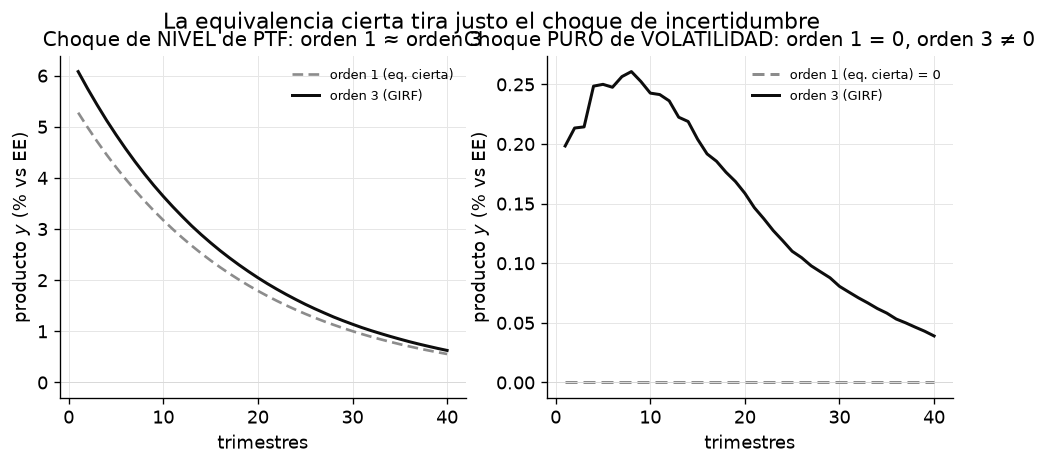

In [4]:
fig, (a0, a1) = plt.subplots(1, 2, figsize=(9.6, 3.7))
a0.plot(h, irf["y_o1"], color="0.55", lw=1.6, ls=(0, (4, 2)), label="orden 1 (eq. cierta)")
a0.plot(h, irf["y_o3"], color="0.05", lw=1.8, label="orden 3 (GIRF)")
a0.axhline(0, color="0.85", lw=0.6)
a0.set_title("Choque de NIVEL de PTF: orden 1 ≈ orden 3")
a0.set_xlabel("trimestres"); a0.set_ylabel("producto $y$ (% vs EE)")
a0.legend(loc="upper right", fontsize=8)
a1.plot(hv, o1, color="0.55", lw=1.8, ls=(0, (4, 2)), label="orden 1 (eq. cierta) = 0")
a1.plot(hv, gv["y"], color="0.05", lw=1.8, label="orden 3 (GIRF)")
a1.axhline(0, color="0.85", lw=0.6)
a1.set_title("Choque PURO de VOLATILIDAD: orden 1 = 0, orden 3 ≠ 0")
a1.set_xlabel("trimestres"); a1.set_ylabel("producto $y$ (% vs EE)")
a1.legend(loc="upper right", fontsize=8)
fig.suptitle("La equivalencia cierta tira justo el choque de incertidumbre")
plt.show()

## 4. La anatomía de la precaución (orden 3)

Aislemos la GIRF de volatilidad para ver el **patrón de signos**. Ante un mundo más incierto, el
agente de orden 3 hace exactamente lo que dicta el motivo precautorio (marginal de consumo convexa,
$u'''>0$): **hoy** consume menos, **ahorra más** (la inversión sube) y —en este RBC de precios
flexibles— **trabaja más**, de modo que el producto **sube** un poco en impacto.

Lee la figura con cuidado: la línea del consumo **está por debajo de cero solo los primeros
trimestres** y luego se queda ligeramente por **encima**. No es una contradicción, es el mecanismo
completo: el ahorro precautorio levanta el **stock de capital**, y ese capital extra sostiene un
consumo más alto más adelante. Todo es pequeño, pero **no es cero**: es la diferencia entre un
modelo lineal y uno que se toma en serio la incertidumbre.

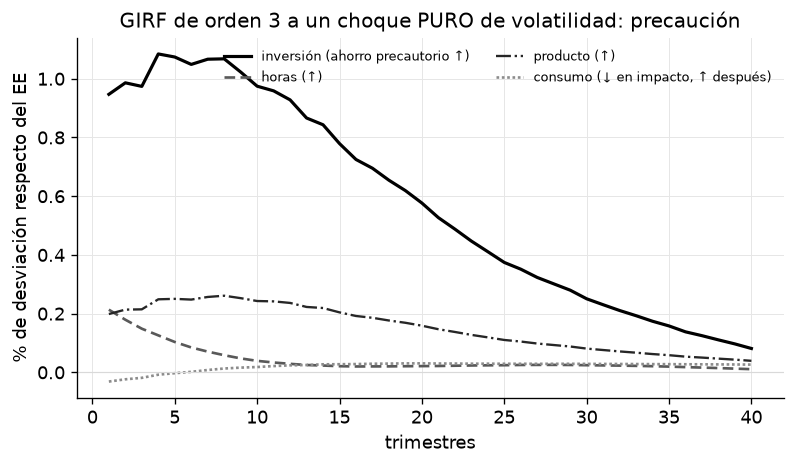

In [5]:
fig, ax = plt.subplots(figsize=(7.6, 3.9))
ax.plot(hv, gv["invest"], color="0.00", lw=1.9, label="inversión (ahorro precautorio ↑)")
ax.plot(hv, gv["l"], color="0.35", lw=1.6, ls=(0, (4, 2)), label="horas (↑)")
ax.plot(hv, gv["y"], color="0.15", lw=1.4, ls="-.", label="producto (↑)")
ax.plot(hv, gv["c"], color="0.55", lw=1.6, ls=(0, (1, 1)), label="consumo (↓ en impacto, ↑ después)")
ax.axhline(0, color="0.85", lw=0.7)
ax.set_title("GIRF de orden 3 a un choque PURO de volatilidad: precaución")
ax.set_xlabel("trimestres"); ax.set_ylabel("% de desviación respecto del EE")
ax.legend(loc="upper right", fontsize=8, ncol=2)
plt.show()

### ¿Por qué los bancos centrales se preocupan por la incertidumbre si a primer orden no hace nada?
Justo porque el mundo **no es de primer orden**. La equivalencia cierta es una *aproximación* que
el banco central no puede permitirse: la precaución (esta figura), el canal de opción real
("esperar a ver", Bloom 2009) y las primas de riesgo (§5) son fuerzas reales de segundo/tercer
orden que un pico de incertidumbre —VIX, dispersión de pronósticos— dispara. El signo del efecto
**depende del modelo** (en un RBC flexible el producto sube por precaución; en un Nuevo-Keynesiano
con rigideces nominales un choque de incertidumbre suele ser **contractivo**), pero en **todos**
comparten una cosa: el efecto es **cero a primer orden**. Preocuparse por la incertidumbre es,
literalmente, negarse a linealizar.

## 5. Desastres raros y los *puzzles* de precios de activos

El segundo frente donde la equivalencia cierta fracasa es la **macro-finanzas**. La prima de riesgo
de un activo es
$$E[R^e]-R^f \;\approx\; -\,\mathrm{Cov}(m_{t+1},\,R^e_{t+1}),$$
donde $m$ es el factor de descuento estocástico (SDF). Esa covarianza **carga sobre los momentos
altos** del SDF (varianza y **asimetría**). Dos afirmaciones distintas, que conviene no confundir:

- Una solución de **primer orden** es equivalente cierta: las primas de riesgo son **exactamente
  cero**, por construcción. No es que sean pequeñas: no existen.
- Un mundo **gaussiano** resuelto exactamente (o a orden 3, da lo mismo, como veremos) **sí** tiene
  prima, pero **minúscula** con una aversión al riesgo razonable, porque solo dispone de la
  **varianza**. Lo que falta es la **asimetría**.

`riesgo_desastres_momentos.csv` cuantifica el desastre por dos vías.

### Barro–Rietz: economía de dotación con desastres raros
CRRA con $\gamma=4$, crecimiento medio del consumo $\mu$, ruido gaussiano $\sigma$, y con
probabilidad $p$ un **desastre** que encoge el consumo una fracción $b$ (aquí $p=1.7\%$, $b=38\%$).
Es una versión **estilizada** de Barro (2006): él calibra $p\approx1.7\%$ anual pero con una
**distribución** de tamaños de desastre (contracciones de 15% a 64% en el siglo XX); aquí usamos un
solo $b$ intermedio, suficiente para ver el mecanismo. Notación del curso: $\gamma$ es la curvatura
CRRA y $\sigma$ la desviación estándar del choque (mazo 03, "Riesgo e incertidumbre").

Comparamos tres mundos:
- **Gaussiano** (sin desastres): solo media y varianza.
- **Orden-3 (Taylor)**: aproxima hasta el **tercer momento** (la asimetría del desastre).
- **Exacto con desastres**: la forma cerrada.

In [6]:
mm = pd.read_csv(DATA / "riesgo_desastres_momentos.csv")
m = dict(zip(mm["momento"], mm["valor"]))

print(f"Calibración Barro–Rietz: gamma={m['param_gamma']:.0f}, beta={m['param_beta']:.2f}, "
      f"p(desastre)={m['param_p_prob_desastre']:.3f}, tamaño b={m['param_b_tamano_desastre']:.2f}")
print("")
print(f"{'mundo':<26}{'tasa libre Rf':>16}{'prima de equity':>18}")
print(f"{'PRIMER ORDEN (eq. cierta)':<26}{'—':>15}{0.0:>16.2f}pp")
print(f"{'Gaussiano (sin desastres)':<26}{m['Rf_gaussiano_exacto_pct']:>14.2f}%{m['prima_equity_gaussiana_exacta_pp']:>16.2f}pp")
print(f"{'Orden-3 (Taylor)':<26}{m['Rf_orden3_taylor_desastres_pct']:>14.2f}%{m['prima_equity_orden3_taylor_desastres_pp']:>16.2f}pp")
print(f"{'Exacto con desastres':<26}{m['Rf_exacto_desastres_pct']:>14.2f}%{m['prima_equity_exacta_desastres_pp']:>16.2f}pp")
print("")
print(f"  Los DOS puzzles: el gaussiano da Rf={m['Rf_gaussiano_exacto_pct']:.1f}% (demasiado alta) "
      f"y prima={m['prima_equity_gaussiana_exacta_pp']:.2f}pp (frente a ~6pp históricos).")
print(f"  Con desastres: Rf baja a {m['Rf_exacto_desastres_pct']:.2f}% y la prima sube a "
      f"{m['prima_equity_exacta_desastres_pp']:.2f}pp -> ambos puzzles se relajan a la vez.")
capta = 100 * m["prima_equity_orden3_taylor_desastres_pp"] / m["prima_equity_exacta_desastres_pp"]
print(f"  El orden-3 (Taylor) capta ~{capta:.0f}% de la prima: atrapa la ASIMETRÍA, se le escapa la CURTOSIS.")
print("")
print("  NO-LINEALIDAD ≠ ASIMETRÍA. En el mundo GAUSSIANO, resolver a orden 3 con Dynare da")
print(f"    Rf = {m['Rf_gaussiano_dynare_orden3_pct']:.4f}% vs exacto {m['Rf_gaussiano_exacto_pct']:.4f}%   |   "
      f"prima = {m['prima_equity_gaussiana_dynare_orden3_pp']:.4f}pp vs exacta {m['prima_equity_gaussiana_exacta_pp']:.4f}pp")
print("    -> subir el orden no compra prima si la distribución es simétrica. Lo que la compra es el DESASTRE.")
sig, gam = m["param_sigma_gaussiana"], m["param_gamma"]
print(f"  Y con la aproximación clásica prima ≈ gamma·sigma² = {gam:.0f}·{sig:.2f}² = {100*gam*sig**2:.2f}pp,")
print(f"    llegar a 6pp en un mundo gaussiano exigiría gamma ≈ {0.06/sig**2:.0f}. Retén ese número.")
assert m["prima_equity_exacta_desastres_pp"] > 10 * m["prima_equity_gaussiana_exacta_pp"]   # desastres >> gaussiano
assert m["Rf_exacto_desastres_pct"] < m["Rf_gaussiano_exacto_pct"]                          # baja la tasa libre
# en el mundo gaussiano, orden 3 y forma cerrada coinciden hasta la cuarta cifra: la no-linealidad sola no basta
assert abs(m["prima_equity_gaussiana_dynare_orden3_pp"] - m["prima_equity_gaussiana_exacta_pp"]) < 0.01

Calibración Barro–Rietz: gamma=4, beta=0.97, p(desastre)=0.017, tamaño b=0.38

mundo                        tasa libre Rf   prima de equity
PRIMER ORDEN (eq. cierta)               —            0.00pp
Gaussiano (sin desastres)          13.57%            0.18pp
Orden-3 (Taylor)                    4.85%            2.77pp
Exacto con desastres                3.43%            3.76pp

  Los DOS puzzles: el gaussiano da Rf=13.6% (demasiado alta) y prima=0.18pp (frente a ~6pp históricos).
  Con desastres: Rf baja a 3.43% y la prima sube a 3.76pp -> ambos puzzles se relajan a la vez.
  El orden-3 (Taylor) capta ~74% de la prima: atrapa la ASIMETRÍA, se le escapa la CURTOSIS.

  NO-LINEALIDAD ≠ ASIMETRÍA. En el mundo GAUSSIANO, resolver a orden 3 con Dynare da
    Rf = 13.5706% vs exacto 13.5711%   |   prima = 0.1822pp vs exacta 0.1819pp
    -> subir el orden no compra prima si la distribución es simétrica. Lo que la compra es el DESASTRE.
  Y con la aproximación clásica prima ≈ gamma·sigma² = 4·

### Los dos *puzzles*, en dos barras
Un modelo resuelto a **primer orden** produce una prima de **exactamente 0**: ni siquiera aparece en
el gráfico. El mundo **gaussiano** resuelto *exactamente* llega a ~$0.18$pp — casi nada frente a los
~6pp históricos. Su tasa libre es ~$13.6\%$ — enorme, frente al ~$1\%$ real histórico. Los
**desastres raros** mueven las dos barras en la dirección correcta. El orden-3 recorre buena parte
del camino (capta la asimetría), pero no todo (le falta la curtosis).

*Los objetivos empíricos son los de Mehra–Prescott (1985): EUA 1889–1978, retornos reales anuales,
prima de equity ≈6pp y tasa libre real ≈1%. Cifra histórica, no un momento estimado aquí.*

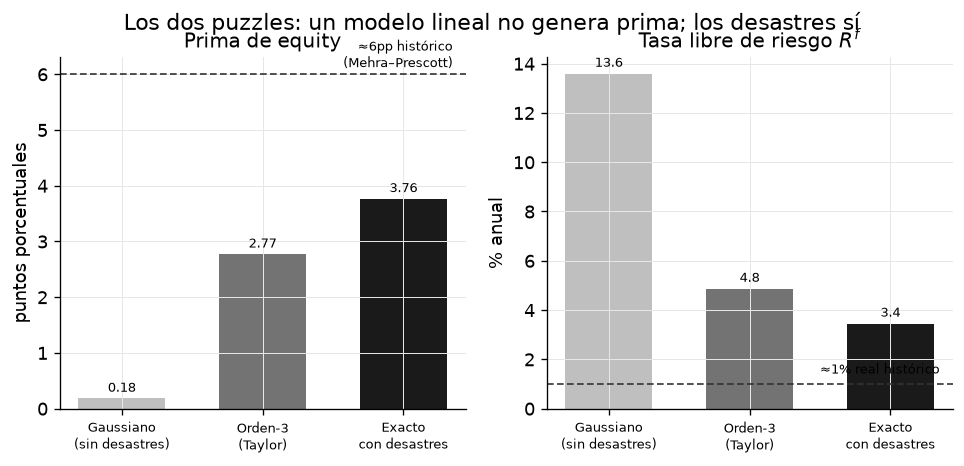

In [7]:
etq = ["Gaussiano\n(sin desastres)", "Orden-3\n(Taylor)", "Exacto\ncon desastres"]
prima = [m["prima_equity_gaussiana_exacta_pp"], m["prima_equity_orden3_taylor_desastres_pp"], m["prima_equity_exacta_desastres_pp"]]
rf = [m["Rf_gaussiano_exacto_pct"], m["Rf_orden3_taylor_desastres_pct"], m["Rf_exacto_desastres_pct"]]
grises = ["0.75", "0.45", "0.10"]
x = np.arange(3)

fig, (b0, b1) = plt.subplots(1, 2, figsize=(9.6, 3.8))
b0.bar(x, prima, color=grises, width=0.62)
b0.axhline(6.0, color="0.2", lw=1.0, ls=(0, (4, 2)))
b0.text(2.35, 6.05, "≈6pp histórico\n(Mehra–Prescott)", fontsize=7.5, ha="right", va="bottom")
b0.set_xticks(x); b0.set_xticklabels(etq, fontsize=8)
b0.set_ylabel("puntos porcentuales"); b0.set_title("Prima de equity")
for xi, v in zip(x, prima):
    b0.text(xi, v + 0.12, f"{v:.2f}", ha="center", fontsize=8)
b1.bar(x, rf, color=grises, width=0.62)
b1.axhline(1.0, color="0.2", lw=1.0, ls=(0, (4, 2)))
b1.text(2.35, 1.3, "≈1% real histórico", fontsize=7.5, ha="right", va="bottom")
b1.set_xticks(x); b1.set_xticklabels(etq, fontsize=8)
b1.set_ylabel("% anual"); b1.set_title("Tasa libre de riesgo $R^f$")
for xi, v in zip(x, rf):
    b1.text(xi, v + 0.3, f"{v:.1f}", ha="center", fontsize=8)
fig.suptitle("Los dos puzzles: un modelo lineal no genera prima; los desastres sí")
plt.show()

### Andreasen (2012): el precio de quedarse en el mundo gaussiano
El otro dato del CSV es un Nuevo-Keynesiano con preferencias Epstein–Zin, resuelto a **orden 3**
(pruning), en su versión **gaussiana** (sin desastres). Este modelo **sí** produce una prima por
plazo del orden de 1 punto **porcentual** en el bono a 40 trimestres —parecida a la que se observa
en los datos—, pero **al precio de una aversión al riesgo disparatada**: $RRA\approx168$.

Que la prima es de ese orden lo dice el propio modelo, sin necesidad de creerle a nadie. En un
modelo **estacionario**, por ley de iteradas, la **pendiente media** de la curva es *idénticamente*
la **prima por plazo media**:
$$\mathbb E[R^{40}]-\mathbb E[R^{1}]=\mathbb E\!\left[R^{40}_t-\tfrac1{40}\textstyle\sum_i \mathbb E_t R^1_{t+i}\right]=\mathbb E[TP^{40}].$$
Si la prima fuera "casi cero", la curva sería **plana**. Comprobémoslo con las dos tasas del CSV.

In [8]:
R1, R40 = m["andreasen_tasa_libre_R1_anual_pct"], m["andreasen_R40_anual_pct"]
pendiente = R40 - R1
TP_pp = m["andreasen_prima_termino_TP_pb"]   # el CSV rotula el campo "_pb", pero la unidad es pp (ver abajo)
print("Andreasen (2012), NK–Epstein–Zin, benchmark GAUSSIANO a orden 3 (pruning):")
print(f"  aversión al riesgo RRA = {m['andreasen_RRA']:.0f}   (¡extrema!)   "
      f"Var(SDF) = {m['andreasen_var_sdf']:.4f}  ->  sd(m) = {np.sqrt(m['andreasen_var_sdf']):.3f}")
print(f"  tasa corta R1 = {R1:.2f}%   tasa larga R40 = {R40:.2f}%   ->  pendiente = {pendiente:.2f} pp")
print(f"  prima por plazo TP = {TP_pp:.2f} pp (= {100*TP_pp:.0f} pb)   [pendiente + corrección de Jensen del bono largo]")
print(f"  exceso de retorno de tenencia del bono a 40 trim. = {m['andreasen_xhr40_anual_pct']:.2f}% anual")
print("")
print(f"  Cota de Hansen–Jagannathan: el Sharpe máximo por trimestre es ~sd(m)/E[m] ≈ {np.sqrt(m['andreasen_var_sdf']):.2f}.")
print("  Con un SDF así de volátil NO hay puzzle de prima; el puzzle es la PREFERENCIA que hace falta.")
print(f"  Moraleja: en un mundo gaussiano la prima solo se compra con aversión absurda "
      f"(RRA≈{m['andreasen_RRA']:.0f}, del mismo orden que el gamma≈{0.06/sig**2:.0f} de la lámina anterior).")
print("  Con DESASTRES basta gamma=4. La asimetría es barata; la varianza sola, carísima.")
# coherencia interna: en un modelo estacionario la pendiente media ES la prima por plazo media
assert pendiente > 0.5                             # la curva NO es plana
assert abs(TP_pp - pendiente) < 0.25               # TP y pendiente coinciden salvo el término de Jensen
assert m["andreasen_RRA"] > 100                    # ...y solo se logra con una RRA disparatada

Andreasen (2012), NK–Epstein–Zin, benchmark GAUSSIANO a orden 3 (pruning):
  aversión al riesgo RRA = 168   (¡extrema!)   Var(SDF) = 0.0170  ->  sd(m) = 0.130
  tasa corta R1 = 5.83%   tasa larga R40 = 6.80%   ->  pendiente = 0.97 pp
  prima por plazo TP = 1.08 pp (= 108 pb)   [pendiente + corrección de Jensen del bono largo]
  exceso de retorno de tenencia del bono a 40 trim. = 1.69% anual

  Cota de Hansen–Jagannathan: el Sharpe máximo por trimestre es ~sd(m)/E[m] ≈ 0.13.
  Con un SDF así de volátil NO hay puzzle de prima; el puzzle es la PREFERENCIA que hace falta.
  Moraleja: en un mundo gaussiano la prima solo se compra con aversión absurda (RRA≈168, del mismo orden que el gamma≈150 de la lámina anterior).
  Con DESASTRES basta gamma=4. La asimetría es barata; la varianza sola, carísima.


## 6. Confrontación: primer orden tira lo que hace interesante a la macro-finanzas

Junta las dos mitades del módulo. La macro estándar del agente representativo, **linealizada**,
impone tres cosas a la vez, y las tres son falsas en los datos:

| A primer orden (equivalencia cierta) | El hecho que sí ocurre |
|---|---|
| Un choque de **volatilidad** no hace **nada** | La precaución mueve inversión/horas; la incertidumbre es recesiva en modelos con rigideces (Bloom 2009; FVGRU 2011) |
| El riesgo no se cotiza: la prima es **exactamente 0** | Prima de equity histórica ~6pp; tasa libre ~1% (Mehra–Prescott 1985, EUA 1889–1978) |
| Solo importan la **media** y la **varianza** (gaussiano) | Con solo varianza hace falta $\gamma\approx150$; con **asimetría** (desastres raros) basta $\gamma=4$ (Barro 2006) |

El mensaje: **la macro de primer orden tira exactamente los momentos altos** —varianza y
asimetría del SDF— que son *el objeto de estudio* de la macro-finanzas. No es que el modelo lineal
esté "un poco mal"; es que, en esta dimensión, **no puede estar bien**: puso a cero, por
construcción, aquello que se quiere medir. Por eso el riesgo, la no-linealidad y los desastres
viven **más allá del primer orden**.

## 7. Laboratorio
Para conectar esta teoría con la medición empírica dentro de `puremacro`:
- **`puremacro.garch.garch11_fit`** — estima un GARCH(1,1): la contraparte empírica del estado de
  **volatilidad estocástica** $\sigma_t$ que dispara la precaución de la §3/§4.
- **`puremacro.realized_vol`** — `realized_variance`, `bipower_variation` y `realized_jump`
  separan la varianza **continua** de los **saltos**: los saltos son la sombra empírica de los
  "desastres" de Barro (§5).
- **`puremacro.uncertainty`** (`composite`, `decomposition`, `lp_long`) — construye índices de
  incertidumbre y traza su efecto dinámico por proyecciones locales: el análogo *reducido-forma*
  del choque de volatilidad estructural de este módulo.
- **`puremacro.volatility`** (`har`, `sigma`, `multivariate`) — modelos HAR-RV y el objeto $\Sigma$
  para volatilidad realizada y comovimiento.

## 8. Preguntas para pensar
1. **La pregunta del gancho.** Si a primer orden un choque de incertidumbre no hace *nada*, ¿por
   qué los bancos centrales vigilan el VIX y la dispersión de pronósticos? ¿Qué supuesto están
   rechazando al hacerlo, y qué órdenes de la solución necesitan para justificar su preocupación?
2. **Nivel vs volatilidad.** Para el choque de **nivel** de PTF, orden 1 y orden 3 casi coinciden;
   para el choque **puro de volatilidad**, orden 1 da cero y orden 3 no. ¿Por qué linealizar es
   "barato" en un caso y **catastrófico** en el otro? (Pista: ¿qué derivada de $g$ estás tirando en
   cada caso?)
3. **Qué capta la perturbación.** El orden-3 (Taylor) recupera ~74% de la prima de equity con
   desastres, pero no el 100%. ¿Qué momento de la distribución del consumo capta el tercer orden y
   cuál se le escapa? ¿Qué tendrías que hacer —en la solución o en la calibración— para cerrar la
   brecha restante?
4. **No-linealidad no es asimetría.** En el mundo *gaussiano*, resolver a orden 3 con Dynare da
   prácticamente la misma prima que la forma cerrada (0.1822 vs 0.1819pp). ¿Por qué subir el orden
   de la perturbación no compra prima ahí, si sí la compra cuando hay desastres? Y ¿por qué el
   $\gamma\approx150$ que exigiría el mundo gaussiano para llegar a 6pp es del mismo orden que la
   $RRA\approx168$ de Andreasen (2012)? ¿Es coincidencia?

### Soluciones (esquema)
1. Rechazan la **equivalencia cierta**. La preocupación se justifica a partir de **tercer orden**
   (donde $g_{\sigma\sigma s}\neq 0$ deja que la volatilidad mueva las decisiones) más el canal de
   opción real y las primas de riesgo (segundo/tercer orden). A primer orden, en efecto, no habría
   nada que vigilar.
2. Un choque de **nivel** carga sobre las derivadas de **primer orden** de $g$ (que sí sobreviven),
   así que la corrección no lineal es de segundo grado y pequeña. Un choque de **volatilidad** carga
   *exclusivamente* sobre términos en $\sigma$: como $g_\sigma=0$, a primer orden no hay coeficiente
   que multiplicar → cero exacto. Linealizar tira precisamente la derivada que ese choque necesita.
3. El tercer orden capta la **asimetría** (tercer momento) del consumo — el sesgo a la baja del
   desastre. Se le escapa la **curtosis** (cuarto momento), el peso de la cola extrema. Para cerrar
   la brecha: subir el orden de la perturbación (4+), usar la forma cerrada/cuadratura, o recalibrar
   para que un desastre "más suave y frecuente" cargue menos en la cola.
4. Porque en una distribución **simétrica** los momentos impares son cero: el término de tercer
   orden del SDF no tiene nada que multiplicar y la prima queda gobernada por la varianza, que ya
   estaba en la solución exacta lognormal. El orden alto abre la puerta a la asimetría; si la
   asimetría no existe, la puerta da a un cuarto vacío. Y no es coincidencia: en el mundo gaussiano
   la prima es ≈$\gamma\sigma^2$, así que con $\sigma=2\%$ toda ruta gaussiana a 6pp pasa por
   $\gamma\sim10^2$, sea el modelo de dotación de Barro–Rietz o el NK–Epstein–Zin de Andreasen. La
   aversión al riesgo es la única palanca que queda cuando la única fuente de riesgo es la varianza.

## 9. Explora con IA
Prueba con el tutor sin conexión (o cualquier asistente de IA):
- "En una frase: ¿qué significa que la solución de primer orden de un DSGE sea 'equivalente cierta'?"
- "¿Por qué un choque puro de volatilidad tiene efecto cero a primer orden pero no a tercer orden?"

In [9]:
print(tutor("En una frase: ¿por qué en un DSGE resuelto a PRIMER orden un choque puro de "
            "volatilidad (más incertidumbre, misma media) no tiene ningún efecto real, y qué "
            "término de la expansión de perturbación hay que recuperar para que sí lo tenga?"))

[tutor sin conexión] No hay ningún motor de LLM local disponible en esta instalación (el tutor es opcional). Puedes instalar uno con `pip install puremacro[local-llm]` más un modelo pequeño (por ejemplo vía Ollama o MLX), o bien usar las indicaciones de la sección «Explora con IA» de esta lección con cualquier asistente de IA.
(motivo: el motor local no está disponible)


**Resumen.** La solución **lineal** del agente representativo es **equivalente cierta**: $g_\sigma=0$,
la varianza desaparece de las reglas de decisión. Lo comprobamos: un choque de **nivel** de PTF da la
**misma forma y la misma persistencia** a orden 1 y a orden 3 (solo cambia la escala, ~15%, y eso
para un choque de 2.5 sd), pero un choque **puro de volatilidad** tiene efecto **exactamente cero** a
orden 1 y una **respuesta de precaución** a orden 3: hoy se invierte y se trabaja más y se consume
menos, y ese capital extra devuelve el consumo por encima de su nivel unos trimestres después — la
incertidumbre importa **solo si abandonas la equivalencia cierta** (Bloom 2009; FVGRU 2011). En
precios de activos, a **primer orden** la prima es **exactamente cero**; un mundo **gaussiano**
resuelto exactamente (o a orden 3: da lo mismo hasta la cuarta cifra) llega apenas a 0.18pp con
$\gamma=4$, y para alcanzar los ~6pp históricos exigiría $\gamma\approx150$ — el mismo orden de
magnitud que la $RRA\approx168$ con la que Andreasen (2012) compra ~1pp de prima por plazo en un
NK–Epstein–Zin gaussiano. Los **desastres raros** logran lo mismo con $\gamma=4$: bajan la tasa libre
de 13.6% a 3.4% y suben la prima de 0.18pp a 3.76pp (Barro 2006), y el orden-3 capta la **asimetría**
(~74% de la prima) pero no la curtosis. Moraleja: **la macro de primer orden tira justo lo que hace
interesante a la macro-finanzas** — los momentos altos del SDF; y subir el orden **no basta** si la
distribución sigue siendo simétrica.

**Referencias.** Rietz (1988, *JME*); Mehra y Prescott (1985, *JME*); Schmitt-Grohé y Uribe (2004,
*JEDC*); Barro (2006, *QJE*); Bloom (2009, *Econometrica*); Fernández-Villaverde, Guerrón-Quintana,
Rubio-Ramírez y Uribe (2011, *AER*); Andreasen (2012, *Review of Economic Dynamics*).